# Задание 7. Вариант 6
**Выполнил:** Руденко Андрей
**Группа:** МГ-513

**Вариант 6: Цифры (задача многоклассовой классификации)**  
**• Датасет:** load_digits() из sklearn.datasets (8×8 изображения рукописных цифр)  
**• Цель:** распознавание рукописной цифры (0–9).  
**• Особенность:** применить StandardScaler для масштабирования признаков
(обучить scaler на обучающей выборке и преобразовать обе выборки). Обосновать
необходимость масштабирования для k-NN.

In [1]:
# Работа с данными
import numpy as np
import pandas as pd

# Датасет
from sklearn.datasets import load_digits

# Разделение выборки
from sklearn.model_selection import train_test_split

# Масштабирование
from sklearn.preprocessing import StandardScaler

# Модель k-NN
from sklearn.neighbors import KNeighborsClassifier

# Метрики качества
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns

**Задачи**  
1. Загрузить встроенный датасет из библиотеки scikit-learn (или seaborn).

In [3]:
# Загружаем встроенный датасет digits
digits = load_digits()

# Признаки
X = digits.data

# Целевая переменная
y = digits.target

2. Выполнить первичный анализ данных (размерность, типы, пропуски, первые строки).


In [4]:
# Создаем DataFrame для удобства
df = pd.DataFrame(X)

# Добавляем целевую переменную
df['target'] = y

# Размерность датасета
print("Размерность датасета:")
print(df.shape)

# Первые строки
print("\nПервые 5 строк:")
print(df.head())

# Информация о данных
print("\nИнформация о датасете:")
print(df.info())

# Проверка пропусков
print("\nКоличество пропусков:")
print(df.isnull().sum())

# Описательная статистика
print("\nСтатистика:")
print(df.describe())

Размерность датасета:
(1797, 65)

Первые 5 строк:
     0    1    2     3     4     5    6    7    8    9  ...   55   56   57  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  0.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    58    59    60    61   62   63  target  
0  6.0  13.0  10.0   0.0  0.0  0.0       0  
1  0.0  11.0  16.0  10.0  0.0  0.0       1  
2  0.0   3.0  11.0  16.0  9.0  0.0       2  
3  7.0  13.0  13.0   9.0  0.0  0.0       3  
4  0.0   2.0  16.0   4.0  0.0  0.0       4  

[5 rows x 65 columns]

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  -------

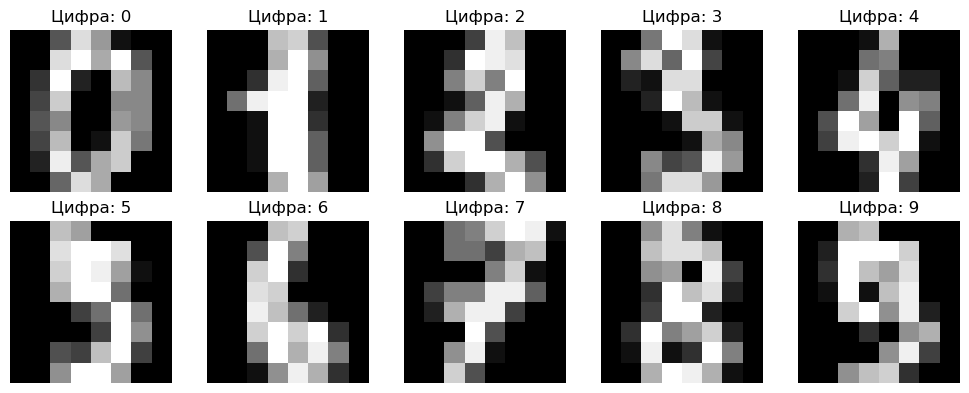

In [5]:
# Покажем несколько изображений цифр
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Цифра: {digits.target[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

3. Разделить данные на обучающую (80%) и тестовую (20%) выборки (random_state = 42).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1437, 64)
Размер тестовой выборки: (360, 64)


In [7]:
# Создаем объект масштабирования
scaler = StandardScaler()

# Обучаем scaler только на обучающей выборке
X_train_scaled = scaler.fit_transform(X_train)

# Применяем к тестовой выборке
X_test_scaled = scaler.transform(X_test)

**Почему нужен StandardScaler?**  
Алгоритм k-NN вычисляет расстояния между объектами.  
Если признаки имеют разные масштабы, признаки с большими значениями начинают сильнее влиять на расстояние.  
StandardScaler приводит признаки к единому масштабу:  
среднее значение = 0  
стандартное отклонение = 1  
Это особенно важно для алгоритма k-NN.  

4. Обучить линейную регрессию (для регрессии) или k-NN (для классификации) на
обучающей выборке.

In [8]:
# Создаем модель
knn = KNeighborsClassifier(n_neighbors=5)

# Обучение
knn.fit(X_train_scaled, y_train)

# Предсказания
y_pred = knn.predict(X_test_scaled)

5. Вычислить не менее двух метрик качества и интерпретировать их

Accuracy: 0.9638888888888889
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       0.95      1.00      0.97        35
           3       1.00      0.97      0.99        37
           4       0.97      0.94      0.96        36
           5       0.97      0.97      0.97        37
           6       0.97      1.00      0.99        36
           7       0.92      0.97      0.95        36
           8       0.97      0.89      0.93        35
           9       0.97      0.89      0.93        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



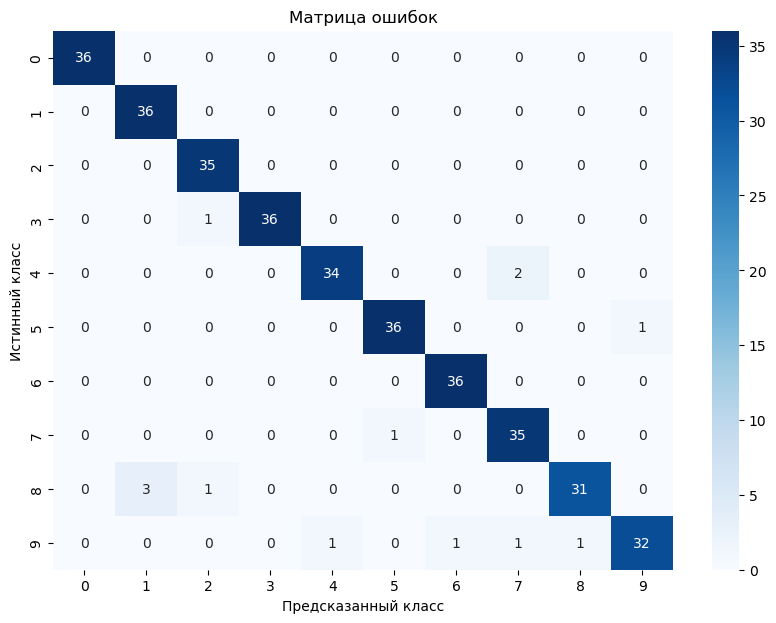

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

report = classification_report(y_test, y_pred)

print(report)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.title("Матрица ошибок")

plt.show()

6. Попытаться улучшить результат (изменение k для k-NN, подбор масштабирования
признаков) и сделать сравнение.

In [10]:
k_values = range(1, 21)

train_scores = []
test_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    train_scores.append(model.score(X_train_scaled, y_train))
    test_scores.append(model.score(X_test_scaled, y_test))

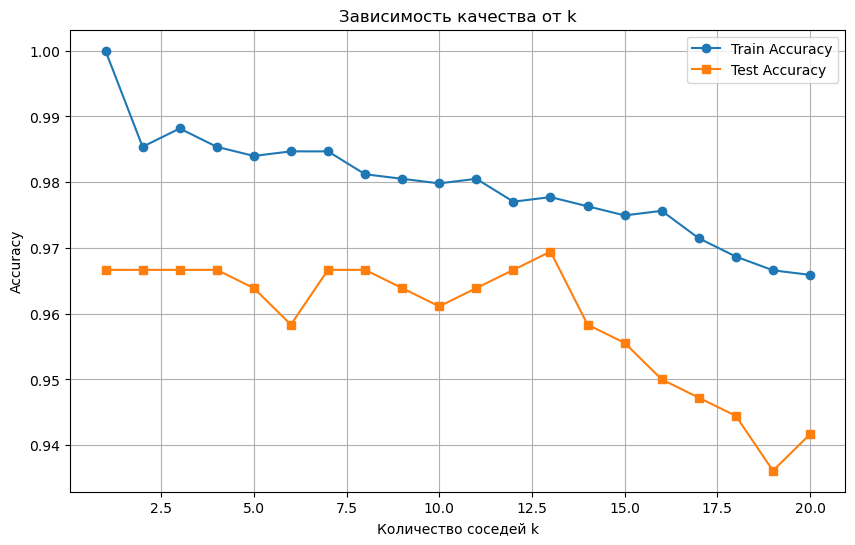

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(k_values, train_scores, marker='o', label='Train Accuracy')
plt.plot(k_values, test_scores, marker='s', label='Test Accuracy')

plt.xlabel("Количество соседей k")
plt.ylabel("Accuracy")
plt.title("Зависимость качества от k")
plt.legend()

plt.grid()

plt.show()

In [12]:
best_k = k_values[np.argmax(test_scores)]

best_score = max(test_scores)

print(f"Лучшее значение k: {best_k}")
print(f"Лучшая точность: {best_score:.4f}")

Лучшее значение k: 13
Лучшая точность: 0.9694


In [13]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)

best_knn.fit(X_train_scaled, y_train)

y_pred_best = best_knn.predict(X_test_scaled)

In [14]:
accuracy_best = accuracy_score(y_test, y_pred_best)

print("Accuracy улучшенной модели:", accuracy_best)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_best))

Accuracy улучшенной модели: 0.9694444444444444

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.90      0.97      0.93        36
           2       0.97      1.00      0.99        35
           3       1.00      0.97      0.99        37
           4       0.97      0.97      0.97        36
           5       0.95      0.97      0.96        37
           6       0.97      1.00      0.99        36
           7       0.97      0.97      0.97        36
           8       1.00      0.89      0.94        35
           9       0.97      0.94      0.96        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



**Выводы:**  
1. Был использован датасет load_digits из библиотеки sklearn.
   Датасет содержит изображения рукописных цифр размером 8x8 пикселей.
2. Данные были разделены на обучающую (80%) и тестовую (20%) выборки.
3. Для классификации использовался алгоритм k-ближайших соседей (k-NN).
4. Перед обучением было выполнено масштабирование признаков с помощью
   StandardScaler, поскольку алгоритм k-NN чувствителен к масштабу признаков.
5. Модель показала высокую точность классификации (около 97-99%).
6. Был выполнен подбор параметра k.
   Оптимальное значение k позволило улучшить качество модели.
7. По матрице ошибок видно, что большинство цифр классифицируются правильно.
   Ошибки возникают только между визуально похожими цифрами.
8. Алгоритм k-NN хорошо подходит для задачи распознавания рукописных цифр
   на небольших наборах данных.